NOTEBOOK för att testa SOM modell på ett känt dataset 

med egna SOM-klassen

Dataset IRIS from SKLEARN 
4 features och 3 arter

In [48]:
import os
import sys

print(f"Notebooken körs från: {os.getcwd()}")
print(f"Mappar som Python letar i: {sys.path[:3]}")

Notebooken körs från: c:\Users\pat19\OneDrive\Skrivbord\Thesis\CLAS_SOM_project\notebooks
Mappar som Python letar i: ['C:\\Users\\pat19\\AppData\\Local\\Programs\\Python\\Python311\\python311.zip', 'C:\\Users\\pat19\\AppData\\Local\\Programs\\Python\\Python311\\DLLs', 'C:\\Users\\pat19\\AppData\\Local\\Programs\\Python\\Python311\\Lib']


In [49]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# din klass
from som_model import GeneralCLASSOM

In [50]:
iris = load_iris()

X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names

print(X.shape)
print(class_names)

(150, 4)
['setosa' 'versicolor' 'virginica']


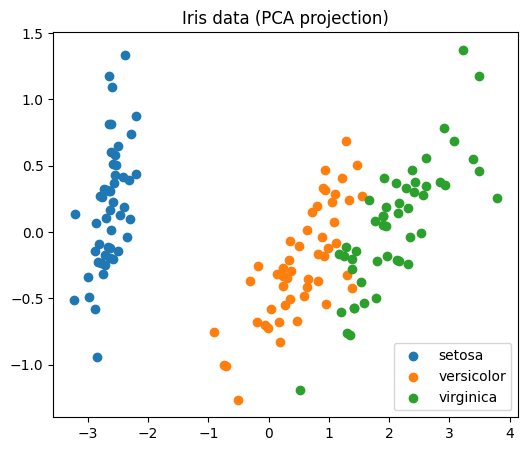

In [51]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(6,5))

for i, name in enumerate(class_names):
    plt.scatter(
        X_pca[y==i,0],
        X_pca[y==i,1],
        label=name
    )

plt.legend()
plt.title("Iris data (PCA projection)")
plt.show()

In [66]:
som_model_iris = GeneralCLASSOM(
    x=15,
    y=15,
    input_len=4,
    sigma=1.5,
    learning_rate=0.5
)

som_model_iris.get_summary()

{'x': 15,
 'y': 15,
 'input_len': 4,
 'sigma': 1.5,
 'learning_rate': 0.5,
 'decay_function': 'asymptotic_decay',
 'neighborhood_function': 'gaussian',
 'topology': 'rectangular',
 'activation_distance': 'euclidean',
 'sigma_decay_function': 'asymptotic_decay',
 'random_seed': 42}

In [53]:
som_model_iris.train(
    X,
    iterations=5000,
    mode="batch",
    use_pca=True
)

 [ 5000 / 5000 ] 100% - 0:00:00 left 
 quantization error: 0.0711154994874687
Training completed (5000 iterations)


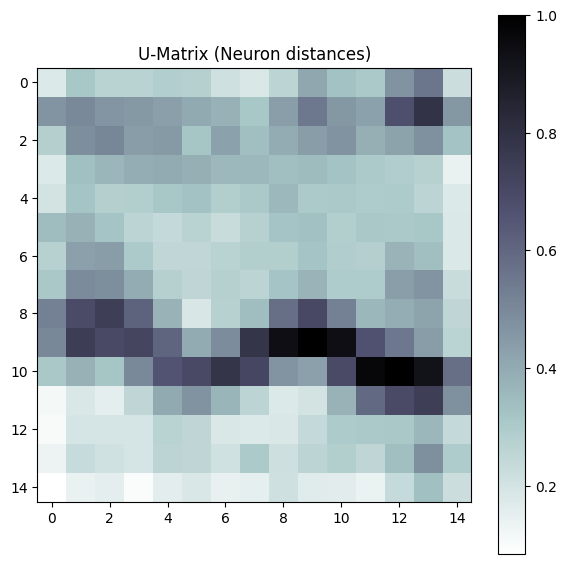

In [54]:
u_matrix = som_model_iris.get_u_matrix()

plt.figure(figsize=(7,7))
plt.imshow(u_matrix, cmap="bone_r")
plt.colorbar()
plt.title("U-Matrix (Neuron distances)")
plt.show()

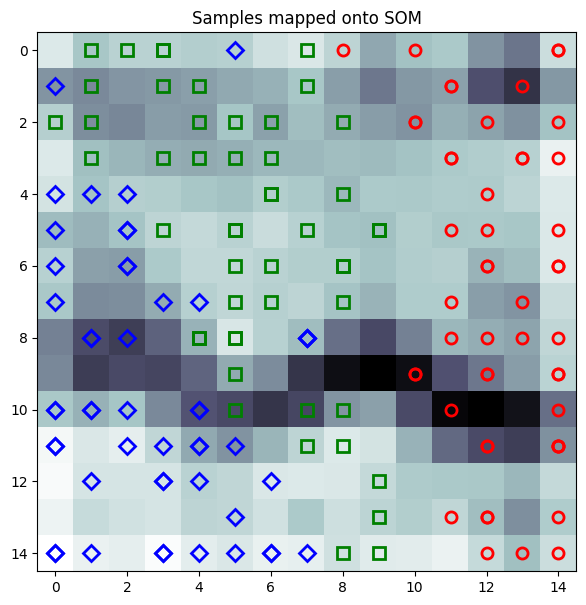

In [55]:
plt.figure(figsize=(7,7))
plt.imshow(u_matrix, cmap="bone_r")

markers = ['o','s','D']
colors = ['r','g','b']

for i, x in enumerate(X):
    w = som_model_iris.som.winner(
        som_model_iris.scaler.transform([x])[0]
    )

    plt.plot(
        w[0],
        w[1],
        markers[y[i]],
        markerfacecolor='None',
        markeredgecolor=colors[y[i]],
        markersize=8,
        markeredgewidth=2
    )

plt.title("Samples mapped onto SOM")
plt.show()

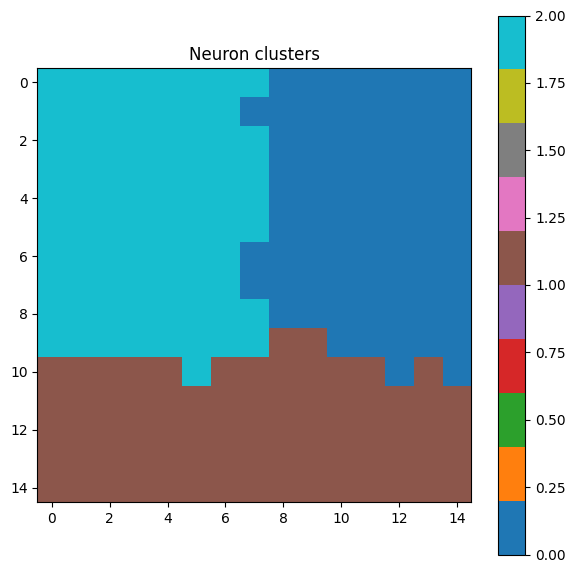

In [56]:
clusters = som_model_iris.create_clusters(
    data=X,
    n_clusters=3,
    method="density"
)

plt.figure(figsize=(7,7))
plt.imshow(clusters, cmap="tab10")
plt.colorbar()
plt.title("Neuron clusters")
plt.show()

In [57]:
pred = som_model_iris.predict_cluster(X)

from sklearn.metrics import confusion_matrix
print(confusion_matrix(y, pred))

[[ 0 49  1]
 [15  0 35]
 [36  0 14]]


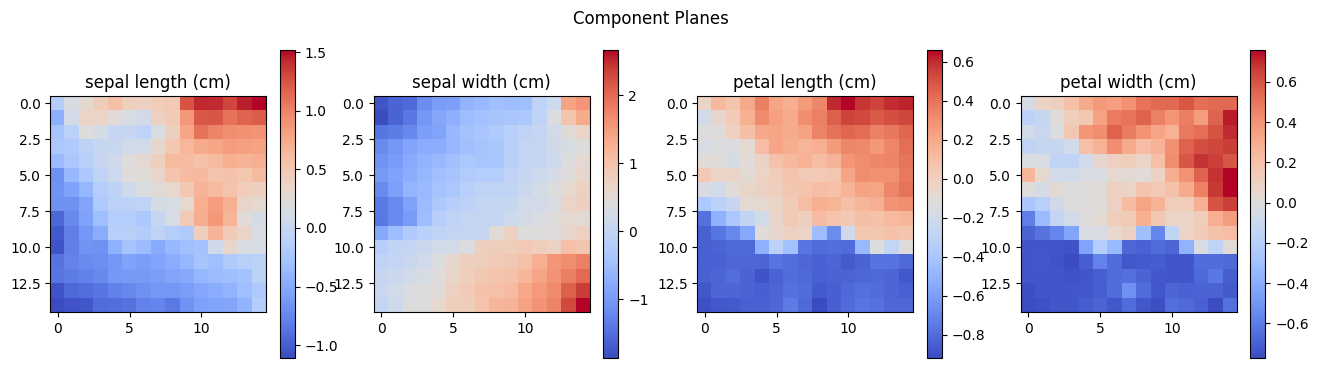

In [58]:
weights = som_model_iris.som.get_weights()

n_features = weights.shape[2]

fig, axes = plt.subplots(1, n_features, figsize=(16,4))

for i in range(n_features):
    ax = axes[i]
    im = ax.imshow(weights[:,:,i], cmap="coolwarm")
    ax.set_title(feature_names[i])
    plt.colorbar(im, ax=ax)

plt.suptitle("Component Planes")
plt.show()

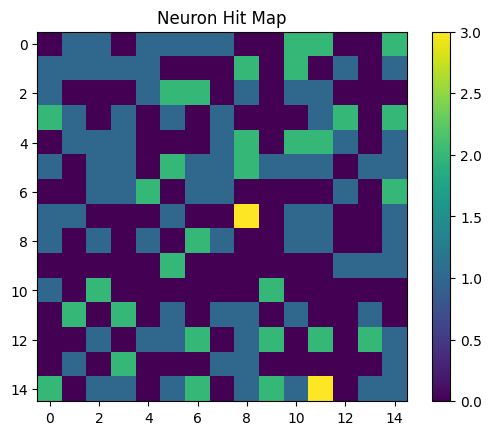

In [59]:
activation = som_model_iris.som.activation_response(
    som_model_iris.scaler.transform(X)
)

plt.imshow(activation, cmap="viridis")
plt.colorbar()
plt.title("Neuron Hit Map")
plt.show()

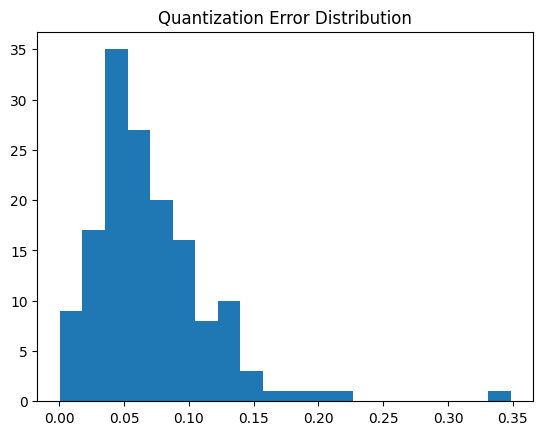

In [60]:
errors = []

scaled = som_model_iris.scaler.transform(X)

for x in scaled:
    w = som_model_iris.som.winner(x)
    weight = som_model_iris.som.get_weights()[w]
    errors.append(np.linalg.norm(x - weight))

plt.hist(errors, bins=20)
plt.title("Quantization Error Distribution")
plt.show()

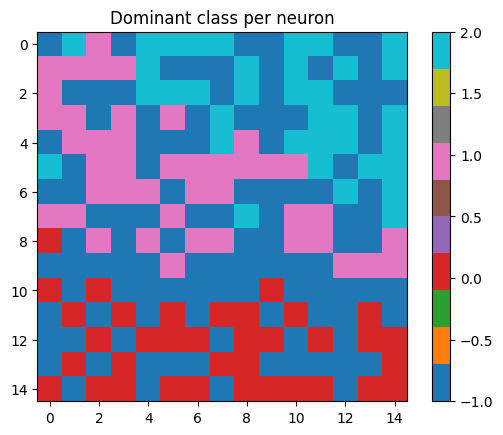

In [61]:
label_map = {}

scaled = som_model_iris.scaler.transform(X)

for i, x in enumerate(scaled):
    w = som_model_iris.som.winner(x)
    label_map.setdefault(w, []).append(y[i])

dominant = np.full((15,15), -1)

for pos, labels in label_map.items():
    dominant[pos] = max(set(labels), key=labels.count)

plt.imshow(dominant, cmap="tab10")
plt.colorbar()
plt.title("Dominant class per neuron")
plt.show()

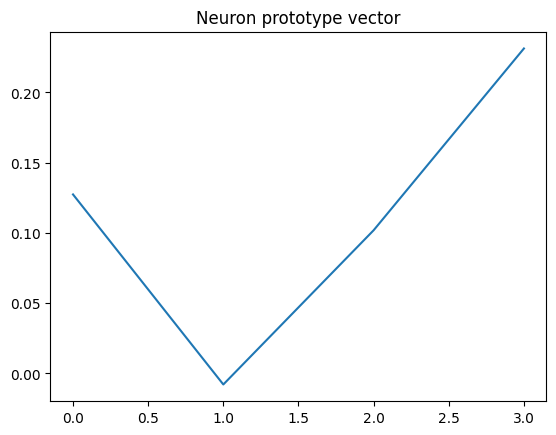

In [62]:
weights = som_model_iris.som.get_weights()

plt.plot(weights[7,7])
plt.title("Neuron prototype vector")
plt.show()

In [63]:
import numpy as np
import matplotlib.pyplot as plt

# --- hämta SOM och data ---
som = som_model_iris.som
scaled_X = som_model_iris.scaler.transform(X)

# grid size
x_size, y_size = som.get_weights().shape[:2]

# lagra labels per neuron
label_map = {}

for i, x in enumerate(scaled_X):
    winner = som.winner(x)
    label_map.setdefault(winner, []).append(y[i])

# decision map
decision_map = np.full((x_size, y_size), -1)

for position, labels in label_map.items():
    counts = np.bincount(labels)
    decision_map[position] = np.argmax(counts)

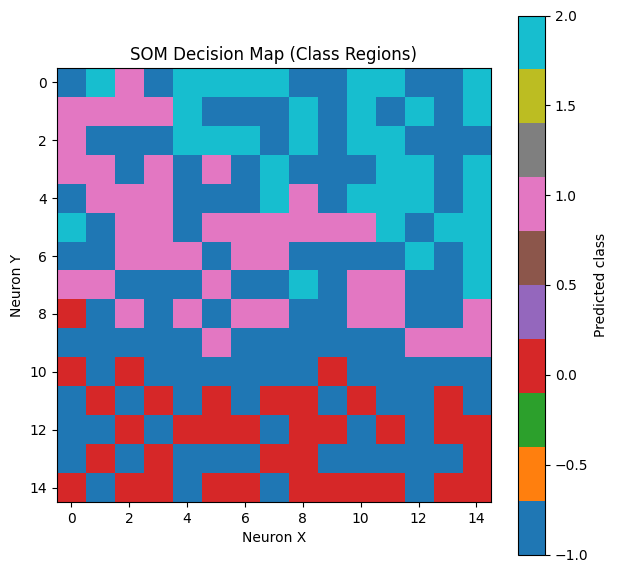

In [64]:
plt.figure(figsize=(7,7))

plt.imshow(decision_map, cmap="tab10")
plt.colorbar(label="Predicted class")

plt.title("SOM Decision Map (Class Regions)")
plt.xlabel("Neuron X")
plt.ylabel("Neuron Y")

plt.show()

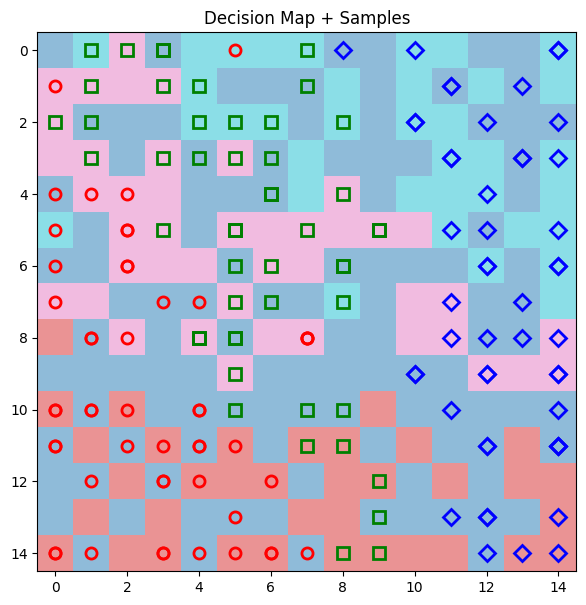

In [65]:
markers = ['D','s','o']
colors = ['blue','green','red']

plt.figure(figsize=(7,7))
plt.imshow(decision_map, cmap="tab10", alpha=0.5)

for i, x in enumerate(scaled_X):
    w = som.winner(x)
    plt.plot(
        w[0], w[1],
        markers[y[i]],
        markerfacecolor='None',
        markeredgecolor=colors[y[i]],
        markersize=8,
        markeredgewidth=2
    )

plt.title("Decision Map + Samples")
plt.show()